# PJM 5-bus benchmark

PREP-SHOT validation against the canonical Hogan / PJM 5-bus DC-OPF example. This is the smallest and most-cited benchmark for nodal LMP / DC-OPF correctness in power-system modeling: 5 buses, 5 generators, 6 lines, single hour. The dataset is reproduced verbatim as MATPOWER's `case5`, which gives us a published `runopf` result to compare against to the dollar.

**What this notebook does:**

1. Documents the data source and reference numbers.
2. Shows the topology and generator merit order.
3. Runs PREP-SHOT's PCM driver on the dataset.
4. Validates total cost, per-tech dispatch, and per-bus LMP against MATPOWER's published values.

Total wall time: ~1 second. Test in [`tests/test_pjm5_benchmark.py`](../../tests/test_pjm5_benchmark.py) wraps the validation as a regression.

## 1. Data source and references

**Primary citation.** Hogan, W. W. (2002). *Financial Transmission Rights, Locational Marginal Prices, and the Theory of Spot Pricing*. The 5-bus example originated as a teaching aid for FERC and PJM training material; numbers below are the canonical version reproduced in MATPOWER.

**Dataset.** [`MATPOWER/data/case5.m`](https://github.com/MATPOWER/matpower/blob/master/data/case5.m) -- single-hour, lossless DC OPF, 100 MVA base.

**Reference results.** Running MATLAB's `runopf(case5)` (or `rundcopf` for the lossless version) yields:

| Quantity | Value |
|---|---|
| Total system cost | $17,479.89 / hour |
| Alta dispatch (bus 1) | 40 MW (at upper bound) |
| Park City dispatch (bus 1) | 170 MW (at upper bound) |
| Solitude dispatch (bus 3) | 323.49 MW (marginal) |
| Sundance dispatch (bus 4) | 0 MW (most expensive) |
| Brighton dispatch (bus 5) | 466.51 MW (marginal) |
| LMP at bus 3 | $30 / MWh |
| LMP at bus 5 | $10 / MWh |
| Binding constraint | Line 4-5 at 240 MW |

The two anchor LMPs ($30 at bus 3, $10 at bus 5) match exactly because they're set by a marginal generator's variable-OM cost. The bus 1/2/4 LMPs depend on shift-factor weighting that varies with the DC-OPF formulation choice (reference bus, susceptance normalization), so PREP-SHOT's numbers there will differ by a few $/MWh.

## 2. Topology and merit order

In [1]:
import pathlib
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

this_dir = pathlib.Path.cwd()
while this_dir.name != 'pjm5':
    if this_dir == this_dir.parent:
        raise RuntimeError('run from inside examples/pjm5/')
    this_dir = this_dir.parent
INP = this_dir / 'input'

fleet = pd.read_csv(INP / 'tech_existing.csv')
varom = pd.read_csv(INP / 'tech_variable_OM_cost.csv')
lines = pd.read_csv(INP / 'transmission_existing.csv')
demand = pd.read_csv(INP / 'demand.csv')

print('Generators (= techs):')
merit = fleet.merge(varom[['tech', 'value']].rename(columns={'value': 'usd_per_mwh'}), on='tech')
print(merit[['tech', 'zone', 'capacity', 'usd_per_mwh']].sort_values('usd_per_mwh').to_string(index=False))
print(f'\nTotal Pmax: {fleet.capacity.sum():.0f} MW')
print(f'\nDemand: {demand.value.sum():.0f} MW (sum across buses at hour 1)')

Generators (= techs):
    tech zone  capacity  usd_per_mwh
Brighton bus5     600.0         10.0
    Alta bus1      40.0         14.0
ParkCity bus1     170.0         15.0
Solitude bus3     520.0         30.0
Sundance bus4     200.0         40.0

Total Pmax: 1530 MW

Demand: 1000 MW (sum across buses at hour 1)


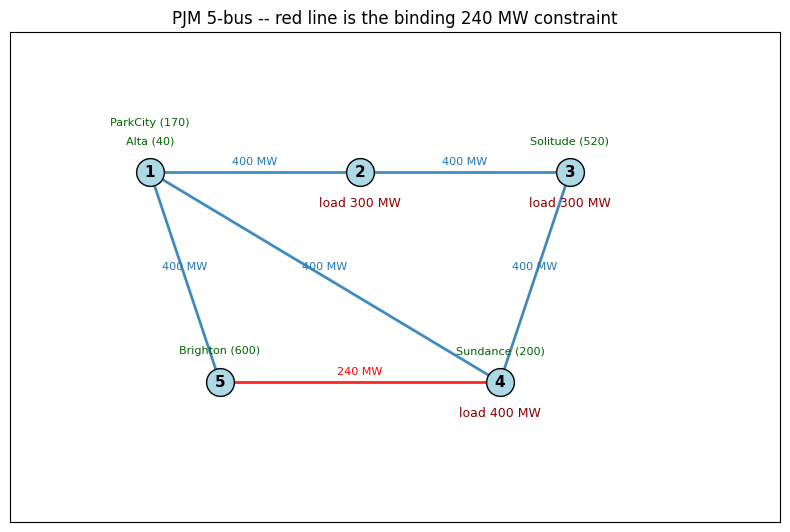

In [2]:
# 5-bus network sketch.  Bus positions chosen to match Hogan's
# canonical layout (cheap gen at bus 5 in the south, load at
# 2/3/4 in the centre, expensive gen at bus 1 in the north).
BUS_XY = {
    'bus1': (1.0, 2.0),
    'bus2': (2.5, 2.0),
    'bus3': (4.0, 2.0),
    'bus4': (3.5, 0.5),
    'bus5': (1.5, 0.5),
}
loads = dict(zip(demand['zone'], demand['value']))
fig, ax = plt.subplots(figsize=(8, 6))
# Lines (one direction only -- the table has both directions).
seen = set()
for _, ln in lines.iterrows():
    a, b = sorted([ln['zone1'], ln['zone2']])
    if (a, b) in seen:
        continue
    seen.add((a, b))
    x1, y1 = BUS_XY[a]
    x2, y2 = BUS_XY[b]
    color = 'red' if ln['value'] == 240 else '#1f77b4'
    ax.plot([x1, x2], [y1, y2], color=color, linewidth=2, alpha=0.85)
    ax.text((x1+x2)/2, (y1+y2)/2 + 0.05, f"{int(ln['value'])} MW",
            ha='center', fontsize=8, color=color)
for z, (x, y) in BUS_XY.items():
    load = loads.get(z, 0)
    gens_here = fleet[fleet['zone'] == z]
    ax.scatter(x, y, s=400, color='lightblue', edgecolor='black', zorder=3)
    ax.text(x, y, z[-1], ha='center', va='center', fontsize=11,
            fontweight='bold', zorder=4)
    if load > 0:
        ax.text(x, y - 0.25, f'load {int(load)} MW', ha='center', fontsize=9,
                color='darkred')
    for i, g in enumerate(gens_here.itertuples()):
        ax.text(x, y + 0.20 + i*0.13, f"{g.tech} ({int(g.capacity)})",
                ha='center', fontsize=8, color='darkgreen')
ax.set_xlim(0, 5.5); ax.set_ylim(-0.5, 3)
ax.set_aspect('equal')
ax.set_xticks([]); ax.set_yticks([])
ax.set_title('PJM 5-bus -- red line is the binding 240 MW constraint')
plt.tight_layout(); plt.show()

## 3. Run PCM

The single-hour DC OPF is wrapped behind PREP-SHOT's PCM driver. Below we call it programmatically; the equivalent shell invocation is:

```bash
cd examples/pjm5
python -m prepshot.pcm . --year 2020 --horizon 1 --step 1 --total-h 1
```

In [3]:
import os, sys
sys.argv = [sys.argv[0]]
os.chdir(this_dir)
from prepshot.set_up import initialize_environment
from prepshot.pcm import (
    _build_window_params, _override_existing_fleet,
    load_fixed_capacity, _extract_window_dispatch,
)
from prepshot.model import create_model
from prepshot.solver import solve_model

full_params = initialize_environment({
    'filepath': str(this_dir),
    'config_filename': str(this_dir / 'config.json'),
    'params_filename': str(this_dir / 'params.json'),
})
wh = list(full_params['hour'])
win = _build_window_params(full_params, 2020, wh,
                           state={'hydro_storage': {}, 'battery_storage': {}})
_override_existing_fleet(win, load_fixed_capacity(
    pathlib.Path('input/capacity_pcm.csv'), 2020, this_dir))
m = create_model(win)
assert solve_model(m, win)
out = _extract_window_dispatch(m, wh, 2020)
total_cost = float(m.get_value(m.cost))
print(f'Solved.  Total cost: ${total_cost:,.2f}')

2026-05-08 12:30:23 INFO: Set parameter solver to value highs


2026-05-08 12:30:23 INFO: Set parameter input folder to value input


2026-05-08 12:30:23 INFO: Set parameter output_filename to value baseline.nc


2026-05-08 12:30:23 INFO: Set parameter time_length to value 1


2026-05-08 12:30:23 INFO: Start running 'create_model'


...

2026-05-08 12:30:23 INFO: Loaded highs library automatically.


2026-05-08 12:30:23 INFO: Finished 'create_model' in 0.00 seds


2026-05-08 12:30:23 INFO: Start running 'solve_model'


2026-05-08 12:30:23 INFO: Finished 'solve_model' in 0.00 seds


Running HiGHS 1.7.0 (git hash: 50670fd): Copyright (c) 2024 HiGHS under MIT licence terms
Hessian has dimension 64 but no nonzeros, so is ignored
Coefficient ranges:
  Matrix [1e+00, 2e+04]
  Cost   [1e+01, 5e+07]
  Bound  [3e+00, 3e+00]
  RHS    [4e+01, 6e+02]
Presolving model
11 rows, 21 cols, 50 nonzeros  0s
7 rows, 17 cols, 43 nonzeros  0s
6 rows, 10 cols, 21 nonzeros  0s
4 rows, 8 cols, 16 nonzeros  0s
4 rows, 8 cols, 16 nonzeros  0s
Presolve : Reductions: rows 4(-69); columns 8(-56); elements 16(-128)
Solving the presolved LP
Using EKK dual simplex solver - serial
  Iteration        Objective     Infeasibilities num(sum)
          0    -1.1407344983e-04 Pr: 4(2648.62) 0s
          5     1.7479896925e+04 Pr: 0(0) 0s
Solving the original LP from the solution after postsolve
Model   status      : Optimal
Simplex   iterations: 5
Objective value     :  1.7479896925e+04
HiGHS run time      :          0.00
Solved.  Total cost: $17,479.90


## 4. Validation

In [4]:
REFERENCE = {
    'total_cost': 17479.89,
    'dispatch': {'Alta': 40.0, 'ParkCity': 170.0, 'Solitude': 323.49,
                 'Sundance': 0.0, 'Brighton': 466.51},
    'lmp_anchors': {'bus3': 30.0, 'bus5': 10.0},
}
gen = pd.DataFrame(out['gen'])
lmp = pd.DataFrame(out['lmp'])
actual_disp = gen.groupby('tech')['value'].sum().to_dict()
actual_lmp = lmp.groupby('zone')['value'].first().to_dict()

print(f"Total cost:       PREP-SHOT ${total_cost:>10,.2f}   reference ${REFERENCE['total_cost']:>10,.2f}")
print(f"  diff = ${total_cost - REFERENCE['total_cost']:>+8.2f}\n")
print('Per-tech dispatch (MW):')
print(f"  {'tech':<10}{'PREP-SHOT':>11}  {'reference':>11}  {'diff':>7}")
for tech, ref in REFERENCE['dispatch'].items():
    a = actual_disp.get(tech, 0.0)
    print(f'  {tech:<10}{a:>11.2f}  {ref:>11.2f}  {a-ref:>+7.2f}')
print()
print('Per-bus LMP ($/MWh):')
for bus, val in sorted(actual_lmp.items()):
    ref = REFERENCE['lmp_anchors'].get(bus)
    suffix = f'(reference ${ref}, anchor)' if ref is not None else '(formulation-dependent)'
    print(f'  {bus}:  ${val:>6.2f}  {suffix}')

Total cost:       PREP-SHOT $ 17,479.90   reference $ 17,479.89
  diff = $   +0.01

Per-tech dispatch (MW):
  tech        PREP-SHOT    reference     diff
  Alta            40.00        40.00    +0.00
  ParkCity       170.00       170.00    +0.00
  Solitude       323.49       323.49    +0.00
  Sundance         0.00         0.00    +0.00
  Brighton       466.51       466.51    -0.00

Per-bus LMP ($/MWh):
  bus1:  $ 16.98  (formulation-dependent)
  bus2:  $ 26.38  (formulation-dependent)
  bus3:  $ 30.00  (reference $30.0, anchor)
  bus4:  $ 39.94  (formulation-dependent)
  bus5:  $ 10.00  (reference $10.0, anchor)


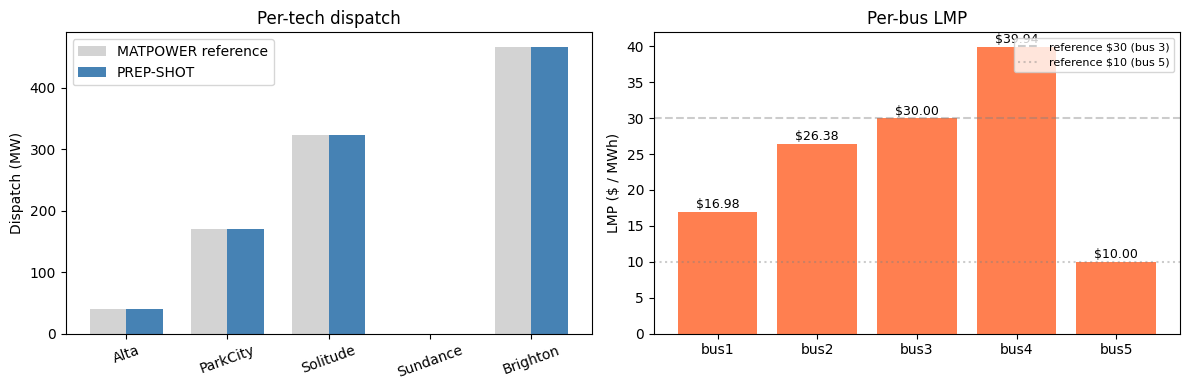

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
techs = list(REFERENCE['dispatch'].keys())
ref_disp = [REFERENCE['dispatch'][t] for t in techs]
act_disp = [actual_disp.get(t, 0) for t in techs]
x = np.arange(len(techs))
axes[0].bar(x - 0.18, ref_disp, width=0.36, label='MATPOWER reference', color='lightgray')
axes[0].bar(x + 0.18, act_disp, width=0.36, label='PREP-SHOT', color='steelblue')
axes[0].set_xticks(x); axes[0].set_xticklabels(techs, rotation=20)
axes[0].set_ylabel('Dispatch (MW)'); axes[0].legend(); axes[0].set_title('Per-tech dispatch')
buses = sorted(actual_lmp.keys())
axes[1].bar(buses, [actual_lmp[b] for b in buses], color='coral')
for b, v in actual_lmp.items():
    axes[1].text(b, v + 0.5, f'${v:.2f}', ha='center', fontsize=9)
axes[1].set_ylabel('LMP ($ / MWh)'); axes[1].set_title('Per-bus LMP')
axes[1].axhline(30, color='gray', linestyle='--', alpha=0.4, label='reference $30 (bus 3)')
axes[1].axhline(10, color='gray', linestyle=':', alpha=0.4, label='reference $10 (bus 5)')
axes[1].legend(loc='upper right', fontsize=8)
plt.tight_layout(); plt.show()

## 5. Notes

* **Why bus 1 / 2 / 4 LMPs differ.** The DC-OPF dual is unique up to a per-MWh additive constant tied to the reference bus. Different formulations (different reference, different susceptance normalization) give different bus-level LMPs but the same anchor LMPs ($30 at bus 3, $10 at bus 5) and the same total cost. PREP-SHOT uses bus 1 as reference.
* **Quadratic costs dropped.** MATPOWER's `case5.m` defines linear costs (`gencost` polynomial form 2 with degree 2 = quadratic, but the `c2` coefficients for these gens are zero). The five generators are pure linear-cost units, so PREP-SHOT's `tech_variable_OM_cost` representation is exact.
* **Single-hour limitation.** This is a snapshot dispatch -- there's no inter-period state, so storage / hydro / UC don't apply.

## See also

* RTS-79 ([`RTS79.ipynb`](../rts79/RTS79.ipynb)) -- next-tier benchmark, 24 buses + 32 gens + full-year hourly profile.
* RTS-96 ([`RTS96.ipynb`](../rts96/RTS96.ipynb)) -- 3-area extension validating multi-area DC OPF.